# Charge Gate Ramsey — Batch Analysis

Scan a root folder for all `*charge_gate_ramsey*` subfolders, run `ChargeGateRamseyAnalyzer`
on each `ds_raw.h5`, and plot **τ₁** and **τ₂** (averaged across charge-gate slices) as a
function of each subfolder / experimental run.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from pathlib import Path
from scqat.protocols.charge_gate_ramsey import ChargeGateRamseyAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [25]:
# ── Root folder that contains all charge_gate_ramsey subfolders ──────────────
ROOT_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\ng_ramsey_statistic"

# Name of the variable in each dataset to use as the signal
# Common choices: "I", "state"
SIGNAL_VAR = "I"

# Conversion factor: charge_gate voltage → charge units
VOLTAGE_TO_CHARGE_FACTOR = 0.5376

# Unit scale for idle_time (e.g. 1/1000 converts ns → µs)
IDLE_TIME_SCALE = 1 / 1000

# Which qubit index to pick from repetition_data() (0-based)
QUBIT_INDEX = 0

# Analysis kwargs forwarded to ChargeGateRamseyAnalyzer.analyze()
ANALYSIS_KWARGS = {
    # "force_model": "beat",
    "f_c_fixed": 0.2e-3 * 1000,          # centre frequency (same units as idle_time axis)
    "abscos_phase_bounds": (-0.5, 0.5),
}

# Glob pattern used to find relevant subfolders
SUBFOLDER_PATTERN = "*charge_gate_ramsey*"

## 2. Discover subfolders

In [26]:
root = Path(ROOT_FOLDER)

# Find all matching subdirectories that contain a ds_raw.h5 file, sorted by name
subfolders = sorted(
    [p for p in root.glob(SUBFOLDER_PATTERN) if p.is_dir() and (p / "ds_raw.h5").exists()]
)

print(f"Found {len(subfolders)} subfolders:")
for sf in subfolders:
    print(f"  {sf.name}")

Found 100 subfolders:
  #3669_LCH_charge_gate_ramsey_0_232113
  #3670_LCH_charge_gate_ramsey_1_232138
  #3671_LCH_charge_gate_ramsey_2_232203
  #3672_LCH_charge_gate_ramsey_3_232228
  #3673_LCH_charge_gate_ramsey_4_232253
  #3674_LCH_charge_gate_ramsey_5_232318
  #3675_LCH_charge_gate_ramsey_6_232343
  #3676_LCH_charge_gate_ramsey_7_232408
  #3677_LCH_charge_gate_ramsey_8_232433
  #3678_LCH_charge_gate_ramsey_9_232458
  #3679_LCH_charge_gate_ramsey_10_232523
  #3680_LCH_charge_gate_ramsey_11_232548
  #3681_LCH_charge_gate_ramsey_12_232612
  #3682_LCH_charge_gate_ramsey_13_232637
  #3683_LCH_charge_gate_ramsey_14_232703
  #3684_LCH_charge_gate_ramsey_15_232728
  #3685_LCH_charge_gate_ramsey_16_232753
  #3686_LCH_charge_gate_ramsey_17_232818
  #3687_LCH_charge_gate_ramsey_18_232844
  #3688_LCH_charge_gate_ramsey_19_232909
  #3689_LCH_charge_gate_ramsey_20_232933
  #3690_LCH_charge_gate_ramsey_21_232958
  #3691_LCH_charge_gate_ramsey_22_233022
  #3692_LCH_charge_gate_ramsey_23_233047
  #3

## 3. Batch analysis

For each subfolder:
1. Load `ds_raw.h5` and apply coordinate scaling.
2. Pick the qubit slice via `repetition_data`.
3. Run `ChargeGateRamseyAnalyzer.extract_parameters()`.
4. Aggregate per-gate **τ₁** and **τ₂** (beat-mode gates only) into a single mean value.

In [27]:
def load_and_prepare(subfolder: Path) -> xr.Dataset | None:
    """Load ds_raw.h5, apply coordinate scaling, and pick the target qubit."""
    try:
        ds = load_xarray_h5(str(subfolder / "ds_raw.h5"))
        ds = ds.assign_coords(
            charge_gate=ds.charge_gate * VOLTAGE_TO_CHARGE_FACTOR,
            idle_time=ds.idle_time * IDLE_TIME_SCALE,
        )
        sq = repetition_data(ds)[QUBIT_INDEX]
        if SIGNAL_VAR != "signal" and SIGNAL_VAR in sq:
            sq = sq.rename({SIGNAL_VAR: "signal"})
        return sq
    except Exception as exc:
        print(f"  [LOAD ERROR] {exc}")
        return None


def aggregate_taus(per_gate_results: list, model_types: list) -> tuple[float, float]:
    """
    Return (mean_tau_1, mean_tau_2) across all charge-gate slices.
    tau_2 is averaged only over gates where the beat model was detected.
    """
    tau_1_vals = []
    tau_2_vals = []
    for res, mt in zip(per_gate_results, model_types):
        if res is None:
            continue
        t1 = res.get("tau_1", np.nan)
        if np.isfinite(t1):
            tau_1_vals.append(t1)
        if mt == "beat":
            t2 = res.get("tau_2", np.nan)
            if np.isfinite(t2):
                tau_2_vals.append(t2)

    mean_tau_1 = float(np.mean(tau_1_vals)) if tau_1_vals else np.nan
    mean_tau_2 = float(np.mean(tau_2_vals)) if tau_2_vals else np.nan
    return mean_tau_1, mean_tau_2


# ── Main batch loop ──────────────────────────────────────────────────────────
analyzer = ChargeGateRamseyAnalyzer()
records = []
all_points = []  # accumulates per-gate (f_1, tau_1) and (f_2, tau_2) pairs across all runs

for sf in subfolders:
    print(f"Processing: {sf.name} …", end=" ", flush=True)
    ds = load_and_prepare(sf)
    if ds is None:
        records.append({"subfolder": sf.name, "tau_1": np.nan, "tau_2": np.nan})
        print("SKIPPED")
        continue

    try:
        results = analyzer.extract_parameters(ds, **ANALYSIS_KWARGS)
        mean_tau_1, mean_tau_2 = aggregate_taus(
            results["per_gate_results"], results["model_types"]
        )
        records.append({"subfolder": sf.name, "tau_1": mean_tau_1, "tau_2": mean_tau_2})
        print(f"τ₁={mean_tau_1:.4g}  τ₂={mean_tau_2:.4g}")

        # Collect per-gate (f_1, tau_1) and (f_2, tau_2) for the scatter plots
        for res, mt in zip(results["per_gate_results"], results["model_types"]):
            if res is None:
                continue
            f1 = res.get("f_1", np.nan)
            t1 = res.get("tau_1", np.nan)
            if np.isfinite(f1) and np.isfinite(t1):
                all_points.append({"freq": f1, "tau": t1, "component": "f₁/τ₁", "subfolder": sf.name})
            if mt == "beat":
                f2 = res.get("f_2", np.nan)
                t2 = res.get("tau_2", np.nan)
                if np.isfinite(f2) and np.isfinite(t2):
                    all_points.append({"freq": f2, "tau": t2, "component": "f₂/τ₂", "subfolder": sf.name})

    except Exception as exc:
        print(f"FAILED ({exc})")
        records.append({"subfolder": sf.name, "tau_1": np.nan, "tau_2": np.nan})

summary = pd.DataFrame(records)
summary.index.name = "run"
summary

Processing: #3669_LCH_charge_gate_ramsey_0_232113 … τ₁=77.54  τ₂=92.87
Processing: #3670_LCH_charge_gate_ramsey_1_232138 … τ₁=89.67  τ₂=83.57
Processing: #3671_LCH_charge_gate_ramsey_2_232203 … τ₁=83.32  τ₂=90.35
Processing: #3672_LCH_charge_gate_ramsey_3_232228 … τ₁=89.47  τ₂=81.17
Processing: #3673_LCH_charge_gate_ramsey_4_232253 … τ₁=85.07  τ₂=79.41
Processing: #3674_LCH_charge_gate_ramsey_5_232318 … τ₁=78.47  τ₂=89.83
Processing: #3675_LCH_charge_gate_ramsey_6_232343 … τ₁=66.13  τ₂=76
Processing: #3676_LCH_charge_gate_ramsey_7_232408 … τ₁=83.47  τ₂=88.76
Processing: #3677_LCH_charge_gate_ramsey_8_232433 … τ₁=82.11  τ₂=103.9
Processing: #3678_LCH_charge_gate_ramsey_9_232458 … τ₁=91.98  τ₂=108.5
Processing: #3679_LCH_charge_gate_ramsey_10_232523 … τ₁=88.62  τ₂=121.9
Processing: #3680_LCH_charge_gate_ramsey_11_232548 … τ₁=87.86  τ₂=85.06
Processing: #3681_LCH_charge_gate_ramsey_12_232612 … τ₁=84.76  τ₂=102.9
Processing: #3682_LCH_charge_gate_ramsey_13_232637 … τ₁=87.32  τ₂=89.47
Proce

,subfolder,tau_1,tau_2
run,,,
0,#3669_LCH_charge_gate_ramsey_0_232113,77.535180,92.869058
1,#3670_LCH_charge_gate_ramsey_1_232138,89.673297,83.572612
2,#3671_LCH_charge_gate_ramsey_2_232203,83.323093,90.352640
3,#3672_LCH_charge_gate_ramsey_3_232228,89.470449,81.170515
4,#3673_LCH_charge_gate_ramsey_4_232253,85.068309,79.414323
...,...,...,...
95,#3764_LCH_charge_gate_ramsey_95_000047,86.435053,77.243853
96,#3765_LCH_charge_gate_ramsey_96_000112,79.513291,84.955826
97,#3766_LCH_charge_gate_ramsey_97_000139,87.008162,89.385078


## 4. Plot τ₁ and τ₂ vs. run

## 4b. τ₁ vs f₁ (all runs, all charge-gate slices)

Each point is one (charge-gate, run) pair. The red curve shows the mean ± std after binning by f₁.

Saved: D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\ng_ramsey_statistic\tau_vs_freq.png


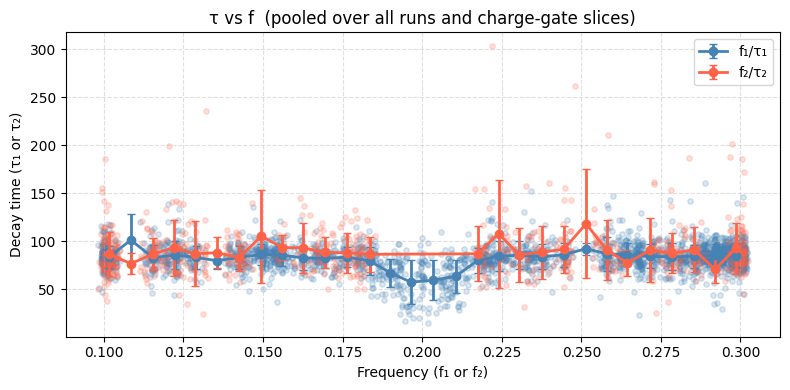

In [28]:
points_df = pd.DataFrame(all_points)

if points_df.empty:
    print("No per-gate data collected — run the batch loop first.")
else:
    COLORS = {"f₁/τ₁": "steelblue", "f₂/τ₂": "tomato"}
    N_BINS = 30

    fig, ax = plt.subplots(figsize=(8, 4))

    for component, grp in points_df.groupby("component"):
        color = COLORS[component]

        # Scatter: all individual points
        ax.scatter(grp["freq"], grp["tau"], alpha=0.2, s=15, color=color)

        # Binned mean ± std
        grp = grp.copy()
        grp["freq_bin"] = pd.cut(grp["freq"], bins=N_BINS)
        binned = (
            grp.groupby("freq_bin", observed=True)["tau"]
            .agg(mean="mean", std="std")
            .dropna(subset=["mean"])
        )
        bin_centers = np.array([iv.mid for iv in binned.index])
        ax.errorbar(
            bin_centers, binned["mean"], yerr=binned["std"],
            fmt="o-", color=color, linewidth=2, markersize=6,
            capsize=3, label=component,
        )

    ax.set_xlabel("Frequency (f₁ or f₂)")
    ax.set_ylabel("Decay time (τ₁ or τ₂)")
    ax.set_title("τ vs f  (pooled over all runs and charge-gate slices)")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout()
    out_path = Path(ROOT_FOLDER) / "tau_vs_freq.png"
    fig.savefig(out_path, dpi=150)
    print(f"Saved: {out_path}")
    plt.show()

Saved: D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\ng_ramsey_statistic\tau_vs_run.png


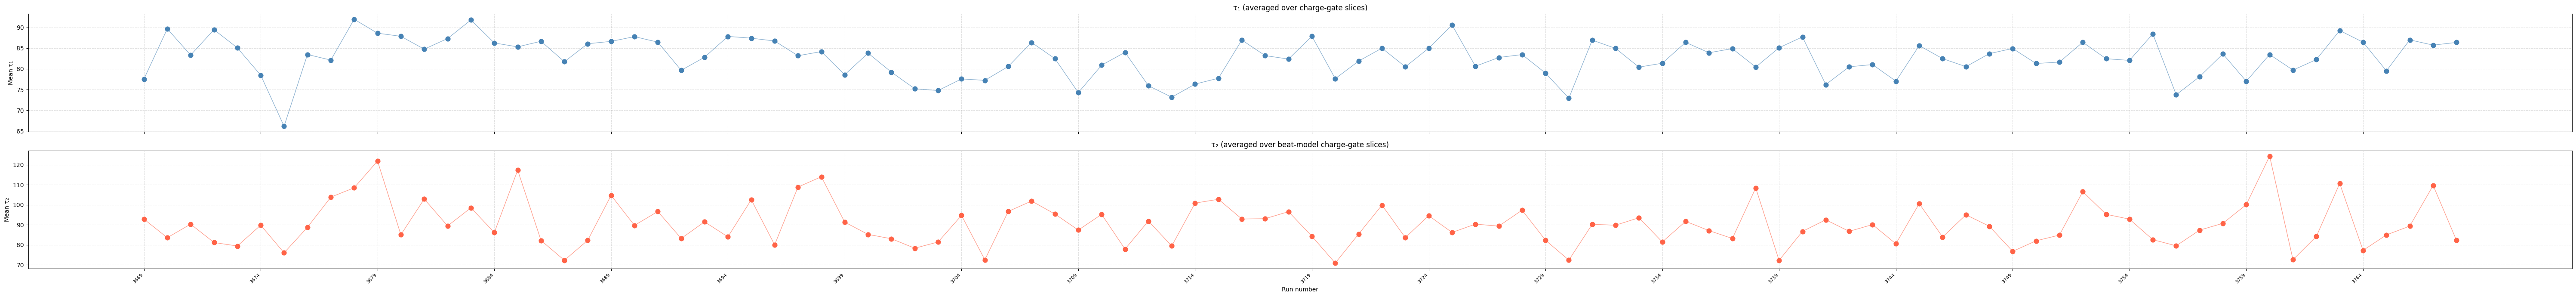

In [29]:
# Extract a short run label: the leading run-number from the folder name, e.g. "#3747" → 3747
def _run_number(name: str) -> int | None:
    m = re.search(r"#(\d+)", name)
    return int(m.group(1)) if m else None

summary["run_number"] = summary["subfolder"].apply(_run_number)
x = summary["run_number"].values
labels = summary["subfolder"].values

fig, axes = plt.subplots(2, 1, figsize=(max(8, len(summary) * 0.6), 7), sharex=True)

# ── τ₁ ──────────────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.scatter(x, summary["tau_1"], color="steelblue", s=60, zorder=3)
ax1.plot(x, summary["tau_1"], color="steelblue", linewidth=1, alpha=0.6)
ax1.set_ylabel("Mean τ₁")
ax1.set_title("τ₁ (averaged over charge-gate slices)")
ax1.grid(True, linestyle="--", alpha=0.4)

# ── τ₂ ──────────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.scatter(x, summary["tau_2"], color="tomato", s=60, zorder=3)
ax2.plot(x, summary["tau_2"], color="tomato", linewidth=1, alpha=0.6)
ax2.set_ylabel("Mean τ₂")
ax2.set_title("τ₂ (averaged over beat-model charge-gate slices)")
ax2.grid(True, linestyle="--", alpha=0.4)

# Shared x-axis labels
ax2.set_xlabel("Run number")
if x is not None and not all(v is None for v in x):
    tick_step = max(1, len(x) // 20)
    ax2.set_xticks(x[::tick_step])
    ax2.set_xticklabels(
        [re.search(r"#(\d+)", l).group(1) if re.search(r"#(\d+)", l) else l for l in labels[::tick_step]],
        rotation=45, ha="right", fontsize=8,
    )

fig.tight_layout()
out_path = Path(ROOT_FOLDER) / "tau_vs_run.png"
fig.savefig(out_path, dpi=150)
print(f"Saved: {out_path}")
plt.show()

## 5. Detailed per-run table

In [30]:
display(summary[["run_number", "subfolder", "tau_1", "tau_2"]].style.format(
    {"tau_1": "{:.6g}", "tau_2": "{:.6g}"}
).set_caption("Batch results: mean τ₁ and τ₂ per run"))

,run_number,subfolder,tau_1,tau_2
run,,,,
0,3669,#3669_LCH_charge_gate_ramsey_0_232113,77.5352,92.8691
1,3670,#3670_LCH_charge_gate_ramsey_1_232138,89.6733,83.5726
2,3671,#3671_LCH_charge_gate_ramsey_2_232203,83.3231,90.3526
3,3672,#3672_LCH_charge_gate_ramsey_3_232228,89.4704,81.1705
4,3673,#3673_LCH_charge_gate_ramsey_4_232253,85.0683,79.4143
5,3674,#3674_LCH_charge_gate_ramsey_5_232318,78.4663,89.8338
6,3675,#3675_LCH_charge_gate_ramsey_6_232343,66.1289,76.0039
7,3676,#3676_LCH_charge_gate_ramsey_7_232408,83.4723,88.7598
8,3677,#3677_LCH_charge_gate_ramsey_8_232433,82.1142,103.854
